In [ ]:
# repo-root bootstrap: notebooks live in notebooks/, code lives one level up
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "spphot_eval.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

data = pd.read_parquet('/scratch/mk27/mj8805/spphot_results_full.parquet')

In [2]:
import numpy as np

In [3]:
data.head()

,sdss_id,plx,e_plx,plx_raw,zeropoint,plx_sp,err_sp,dist_sp_kpc,r_med_photogeo_pc,sample,train,spec_bad_frac
0,100000028,0.164583,0.023733,0.120654,-0.043929,0.180679,0.017489,5.534676,5847.649902,B,False,0.101691
1,100000156,0.058013,0.035814,0.015124,-0.042889,0.123426,0.011947,8.102014,10633.925781,B,False,0.107172
2,100000167,0.164350,0.016947,0.122790,-0.041560,0.141999,0.013745,7.042312,5986.399902,B,True,0.097259
3,100000172,0.142142,0.020179,0.101950,-0.040192,0.232895,0.022543,4.293774,7088.578125,A,False,0.100991
4,100000181,0.134440,0.017905,0.083680,-0.050760,0.099350,0.009617,10.065435,7917.260254,B,False,0.097376


In [4]:
data_filt = data[(data['plx'] < 2) & (data['plx'] > 0) & (data['plx_sp'] < 2) & (data['plx_sp'] > 0)]

In [5]:
len(data_filt)

705804

# PLOT PDF

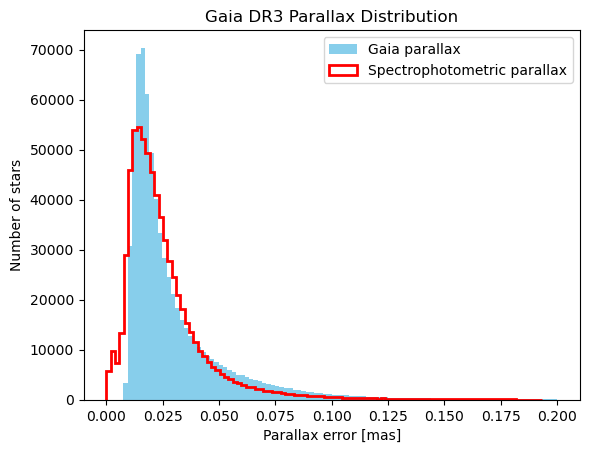

In [6]:
data_filt_hist = data_filt[data_filt['e_plx'] < 0.2]
plt.hist(data_filt_hist['e_plx'], bins=100, color='skyblue', label='Gaia parallax');
plt.hist(data_filt_hist['err_sp'], bins=100, color='red', label='Spectrophotometric parallax', histtype='step', linewidth=2);
plt.xlabel('Parallax error [mas]');
plt.ylabel('Number of stars');
plt.title('Gaia DR3 Parallax Distribution');
plt.legend();
plt.show();

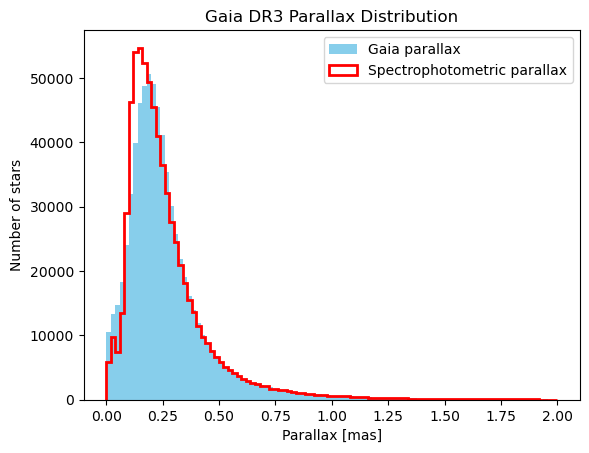

In [7]:
plt.hist(data_filt['plx'], bins=100, color='skyblue', label='Gaia parallax');
plt.hist(data_filt['plx_sp'], bins=100, color='red', label='Spectrophotometric parallax', histtype='step', linewidth=2);
plt.xlabel('Parallax [mas]');
plt.ylabel('Number of stars');
plt.title('Gaia DR3 Parallax Distribution');
plt.legend();
plt.show();


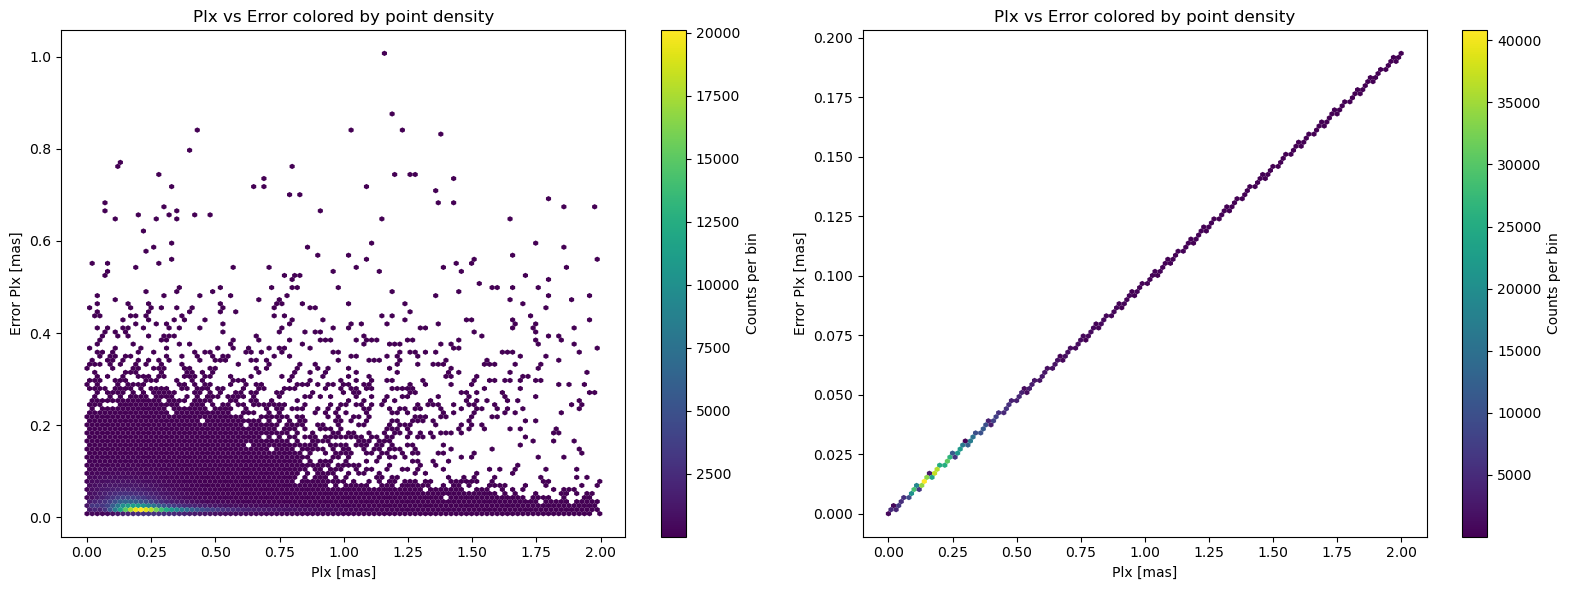

In [15]:
# Use a 2d histogram (hexbin) for much faster density plotting

fig, ax = plt.subplots(ncols=2, figsize=(16,6))

x = data_filt['plx'].values
y = data_filt['e_plx'].values
x2 = data_filt['plx_sp'].values
y2 = data_filt['err_sp'].values

hb = ax[0].hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[0].set_xlabel('Plx [mas]')
ax[0].set_ylabel('Error Plx [mas]')
ax[0].set_title('Plx vs Error colored by point density')
fig.colorbar(hb, ax=ax[0], label='Counts per bin')

hb2 = ax[1].hexbin(x2, y2, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[1].set_xlabel('Plx [mas]')
ax[1].set_ylabel('Error Plx [mas]')
ax[1].set_title('Plx vs Error colored by point density')
fig.colorbar(hb2, ax=ax[1], label='Counts per bin')

fig.tight_layout()
plt.show()

# compare with their plots

# plot fractional error & err in distance

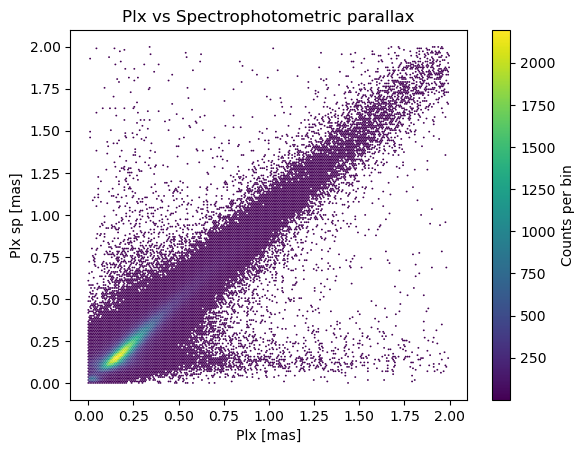

In [20]:
x = data_filt['plx'].values
y = data_filt['plx_sp'].values

hb = plt.hexbin(x, y, gridsize=200, cmap='viridis', mincnt=1, linewidths=0)
plt.xlabel('Plx [mas]')
plt.ylabel('Plx sp [mas]')
plt.title('Plx vs Spectrophotometric parallax')
plt.colorbar(label='Counts per bin')

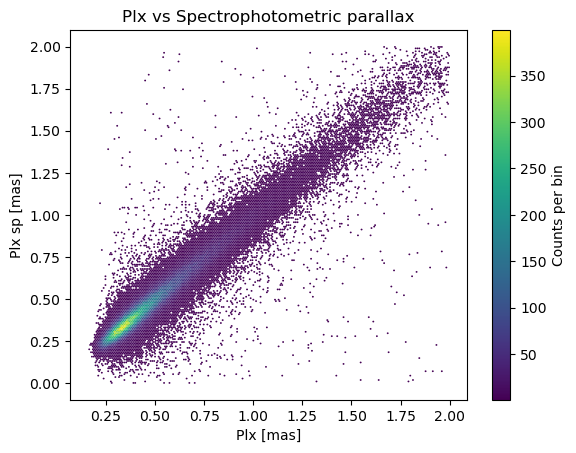

In [19]:
data_good = data_filt[(data_filt['plx']/data_filt['e_plx']) > 20.0]
x = data_good['plx'].values
y = data_good['plx_sp'].values

hb = plt.hexbin(x, y, gridsize=200, cmap='viridis', mincnt=1, linewidths=0)
plt.xlabel('Plx [mas]')
plt.ylabel('Plx sp [mas]')
plt.title('Plx vs Spectrophotometric parallax')
plt.colorbar(label='Counts per bin')